# Matrix-Free Rayleigh Relaxation — full Colab workflow

This notebook keeps the complete workflow for the revised paper:

1. correctness test,
2. harmonic oscillator sanity test,
3. hydrogen atom single-grid test,
4. hydrogen atom \(N\)-sweep and energy-convergence plots,
5. large-\(N\) hydrogen mid-slice heatmap,
6. \( \mathrm{H}_2^+ \) energy curve,
7. \( \mathrm{H}_2^+ \) bond-plane and transverse heatmaps.

Before running, choose **Runtime → Change runtime type → GPU**.


In [1]:
!nvidia-smi


Sun Jul  5 12:52:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Get the repository

Use Option A after the public repository exists. Use Option B for the ZIP bundle.


In [2]:
# OPTION A: clone the future public repository.
REPO_URL = "https://github.com/mahdi-sasar/matrix-free-rayleigh-relaxation.git"

!rm -rf /content/matrix-free-rayleigh-relaxation /content/matrix_free_rayleigh_relaxation
!git clone $REPO_URL /content/matrix-free-rayleigh-relaxation
%cd /content/matrix-free-rayleigh-relaxation


Cloning into '/content/matrix-free-rayleigh-relaxation'...
remote: Enumerating objects: 103, done.
remote: Counting objects: 100% (103/103), done.
remote: Compressing objects: 100% (101/101), done.
remote: Total 103 (delta 49), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (103/103), 77.38 KiB | 683.00 KiB/s, done.
Resolving deltas: 100% (49/49), done.
/content/matrix-free-rayleigh-relaxation


## 2. Install lightweight dependencies

Do not reinstall TensorFlow in Colab unless absolutely necessary. The `--no-deps` flag is intentional.


In [3]:
!python -m pip install -q -r requirements-colab.txt
!python -m pip install -q -e . --no-deps


  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for matrix-free-rayleigh-relaxation (pyproject.toml) ... done


## 4. Configure TensorFlow and plotting defaults


In [19]:
import json, os, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from IPython.display import Image, display

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as exc:
        print("Could not set memory growth:", exc)

tf.keras.backend.set_floatx("float64")
print("Default Keras float:", tf.keras.backend.floatx())

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})


TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Default Keras float: float64


## 5. Helper functions

These helpers keep paths robust whether outputs are local or in Google Drive.


In [5]:
SEARCH_ROOTS = [
    Path("results"),
    Path("/content/drive/MyDrive/mrsr_results"),
    Path("/content/drive/My Drive/mrsr_results"),
]

def latest_csv(named):
    candidates = []
    for root in SEARCH_ROOTS:
        if root.exists():
            candidates.extend(root.glob(f"**/{named}"))
    if not candidates:
        raise FileNotFoundError(f"Could not find {named} under {SEARCH_ROOTS}")
    return max(candidates, key=lambda p: p.stat().st_mtime)

def infer_box_from_metadata(outdir, fallback):
    meta_path = Path(outdir) / "metadata.json"
    if meta_path.exists():
        with open(meta_path, "r") as f:
            meta = json.load(f)
        return float(meta.get("box", fallback))
    return float(fallback)

def pretty_hydrogen_slice(slice_csv, box, out_png, title):
    arr = pd.read_csv(slice_csv, header=None).values
    density = arr**2
    fig, ax = plt.subplots(figsize=(6.3, 5.3), constrained_layout=True)
    extent = [0, box, 0, box]
    im = ax.imshow(density.T, origin="lower", extent=extent, aspect="equal", cmap="YlOrRd")
    if np.nanmax(density) > np.nanmin(density):
        xs = np.linspace(extent[0], extent[1], density.shape[0])
        ys = np.linspace(extent[2], extent[3], density.shape[1])
        X, Y = np.meshgrid(xs, ys, indexing="ij")
        levels = np.linspace(np.nanmin(density), np.nanmax(density), 14)[1:-1]
        ax.contour(X, Y, density, levels=levels, colors="white", linewidths=0.45, alpha=0.72)
    ax.set_xlabel("X (Bohr)")
    ax.set_ylabel("Y (Bohr)")
    ax.set_title(title)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"$|\psi|^2$")
    fig.savefig(out_png, bbox_inches="tight")
    fig.savefig(Path(out_png).with_suffix(".pdf"), bbox_inches="tight")
    print("Saved:", out_png)
    print("Saved:", Path(out_png).with_suffix(".pdf"))
    plt.show()

def nice_energy_plot(df, out_png, title=r"$\mathrm{H}_2^+$ finite-box potential-energy curve"):
    df = df.sort_values("R_Bohr").copy()
    idx = int(df["total_energy_Ry"].idxmin())
    rbest = float(df.loc[idx, "R_Bohr"])
    ebest = float(df.loc[idx, "total_energy_Ry"])

    fig, ax = plt.subplots(figsize=(7.2, 4.8), constrained_layout=True)
    ax.plot(df["R_Bohr"], df["electronic_energy_Ry"], marker="o", markersize=5, linewidth=2.0, color="black", markerfacecolor="black", markeredgecolor="black", label="Electronic energy")
    ax.plot(df["R_Bohr"], df["total_energy_Ry"], marker="s", markersize=5, linewidth=2.0, color="red", markerfacecolor="red", markeredgecolor="red", label="Total energy")
    ax.scatter([rbest], [ebest], s=90, zorder=5, color="red", edgecolors="red", label=fr"Lowest sampled total ($R={rbest:.3f}$ Bohr)")
    ax.axvline(rbest, linestyle="--", linewidth=1.0, color="red", alpha=0.5)
    ax.set_xlabel("Internuclear separation $R$ (Bohr)")
    ax.set_ylabel("Energy (Ry)")
    ax.set_title(title)
    ax.grid(True, alpha=0.25, linewidth=0.8)
    ax.legend(frameon=True)
    fig.savefig(out_png, bbox_inches="tight")
    fig.savefig(Path(out_png).with_suffix(".pdf"), bbox_inches="tight")
    print("Saved:", out_png)
    print("Saved:", Path(out_png).with_suffix(".pdf"))
    plt.show()
    return idx, rbest, ebest


# Part A — Hydrogen atom tests

The hydrogen atom remains the main single-center benchmark. The cells below include both a single-grid test and the \(N\)-sweep needed for the energy-convergence figure.


## 8. Hydrogen single-grid run


In [6]:
!python examples/run_hydrogen_box.py \
    --n 128 \
    --box 10.0 \
    --init gaussian \
    --sigma 0.5 \
    --tol 1e-8 \
    --max-iter 100000 \
    --out results/colab_hydrogen_64

with open("results/colab_hydrogen_64/metadata.json") as f:
    h_meta = json.load(f)
h_meta


Coulomb center = (5.029243360342843, 5.029243360342843, 5.029243360342843); nearest grid-node distance = 1.753999e-02 Bohr
2026-07-05 12:53:35.756586: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1783256015.758119    1123 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
iter=      0  E=-7.618204576584e-01  residual=6.421e-01  norm=1.000000
iter=     10  E=-7.801023812580e-01  residual=5.498e-01  norm=1.000000
iter=     20  E=-7.934602141771e-01  residual=5.151e-01  norm=1.000000
iter=     30  E=-8.046739201530e-01  residual=4.878e-01  norm=1.000000
iter=     40  E=-8.143958377041e-01  residual=4.644e-01  norm=1.000000
iter=     50  E=-8.229737331064e-01  residual=4.436e-01  norm=1.000000
iter=     60  

FileNotFoundError: [Errno 2] No such file or directory: 'results/colab_hydrogen_64/metadata.json'

## 9. Hydrogen single-grid mid-slice heatmap


In [ ]:
h_box = infer_box_from_metadata("results/colab_hydrogen_64", fallback=10.0)
pretty_hydrogen_slice(
    "results/colab_hydrogen_64/psi_mid_z.csv",
    box=h_box,
    out_png="results/colab_hydrogen_64/psi_mid_z_density_pretty.png",
    title="Hydrogen in a box: mid-slice probability density",
)


## 10. Hydrogen \(N\)-sweep: quick run

This generates the data for energy versus number of grid points. The quick values below are for checking the workflow. For the paper, use the production template in the next cell.


In [7]:
!python scripts/run_scaling_hydrogen.py \
    --n-values 48 64 80 96 112 128 \
    --box 10.0 \
    --tol 1e-8 \
    --sigma 0.5 \
    --max-iter 120000 \
    --check-every 20 \
    --outdir results/hydrogen_n_sweep_quick

hyd_csv = Path("results/hydrogen_n_sweep_quick/hydrogen_scaling.csv")
hyd = pd.read_csv(hyd_csv)
display(hyd)


Streaming output truncated to the last 5000 lines.
iter=    720  E=-1.087720784314e+00  residual=9.718e-03  norm=1.000000
iter=    740  E=-1.087775096906e+00  residual=9.039e-03  norm=1.000000
iter=    760  E=-1.087822086742e+00  residual=8.407e-03  norm=1.000000
iter=    780  E=-1.087862742536e+00  residual=7.820e-03  norm=1.000000
iter=    800  E=-1.087897919184e+00  residual=7.274e-03  norm=1.000000
iter=    820  E=-1.087928355949e+00  residual=6.766e-03  norm=1.000000
iter=    840  E=-1.087954692161e+00  residual=6.294e-03  norm=1.000000
iter=    860  E=-1.087977480770e+00  residual=5.854e-03  norm=1.000000
iter=    880  E=-1.087997200049e+00  residual=5.446e-03  norm=1.000000
iter=    900  E=-1.088014263704e+00  residual=5.066e-03  norm=1.000000
iter=    920  E=-1.088029029612e+00  residual=4.712e-03  norm=1.000000
iter=    940  E=-1.088041807371e+00  residual=4.384e-03  norm=1.000000
iter=    960  E=-1.088052864824e+00  residual=4.078e-03  norm=1.000000
iter=    980  E=-1.0880624

,n_per_dim,voxels_total,interior_points,h_Bohr,energy_Ry,energy_error_vs_free_Ry,abs_energy_error_vs_free_Ry,iterations,converged,tau,sigma,elapsed_seconds,seconds_per_iteration,nearest_grid_node_distance_bohr,slice_dir
0,48,110592,97336,0.212766,-1.088124,-0.088124,0.088124,4560,True,0.003257,0.5,85.549906,0.018761,0.047395,NaN
1,64,262144,238328,0.158730,-1.041817,-0.041817,0.041817,8160,True,0.001878,0.5,153.567720,0.018820,0.035358,NaN
2,80,512000,474552,0.126582,-1.023883,-0.023883,0.023883,12700,True,0.001220,0.5,238.459525,0.018776,0.028197,NaN
3,96,884736,830584,0.105263,-1.015034,-0.015034,0.015034,18180,True,0.000856,0.5,343.426618,0.018890,0.023448,NaN
4,112,1404928,1331000,0.090090,-1.010004,-0.010004,0.010004,24640,True,0.000634,0.5,477.679916,0.019386,0.020068,NaN
5,128,2097152,2000376,0.078740,-1.006868,-0.006868,0.006868,32040,True,0.000488,0.5,627.146972,0.019574,0.017540,results/hydrogen_n_sweep_quick/N_0128


## 12. Publication plots for Hydrogen energy convergence with exponential fit

This plots:
- final energy versus total grid points with an exponential-decay fit,
- absolute approach toward the free-hydrogen value \(-1\) Ry,
- wall time versus total grid points.


Using hydrogen sweep folder: results/hydrogen_n_sweep_quick
Using CSV: results/hydrogen_n_sweep_quick/hydrogen_scaling.csv


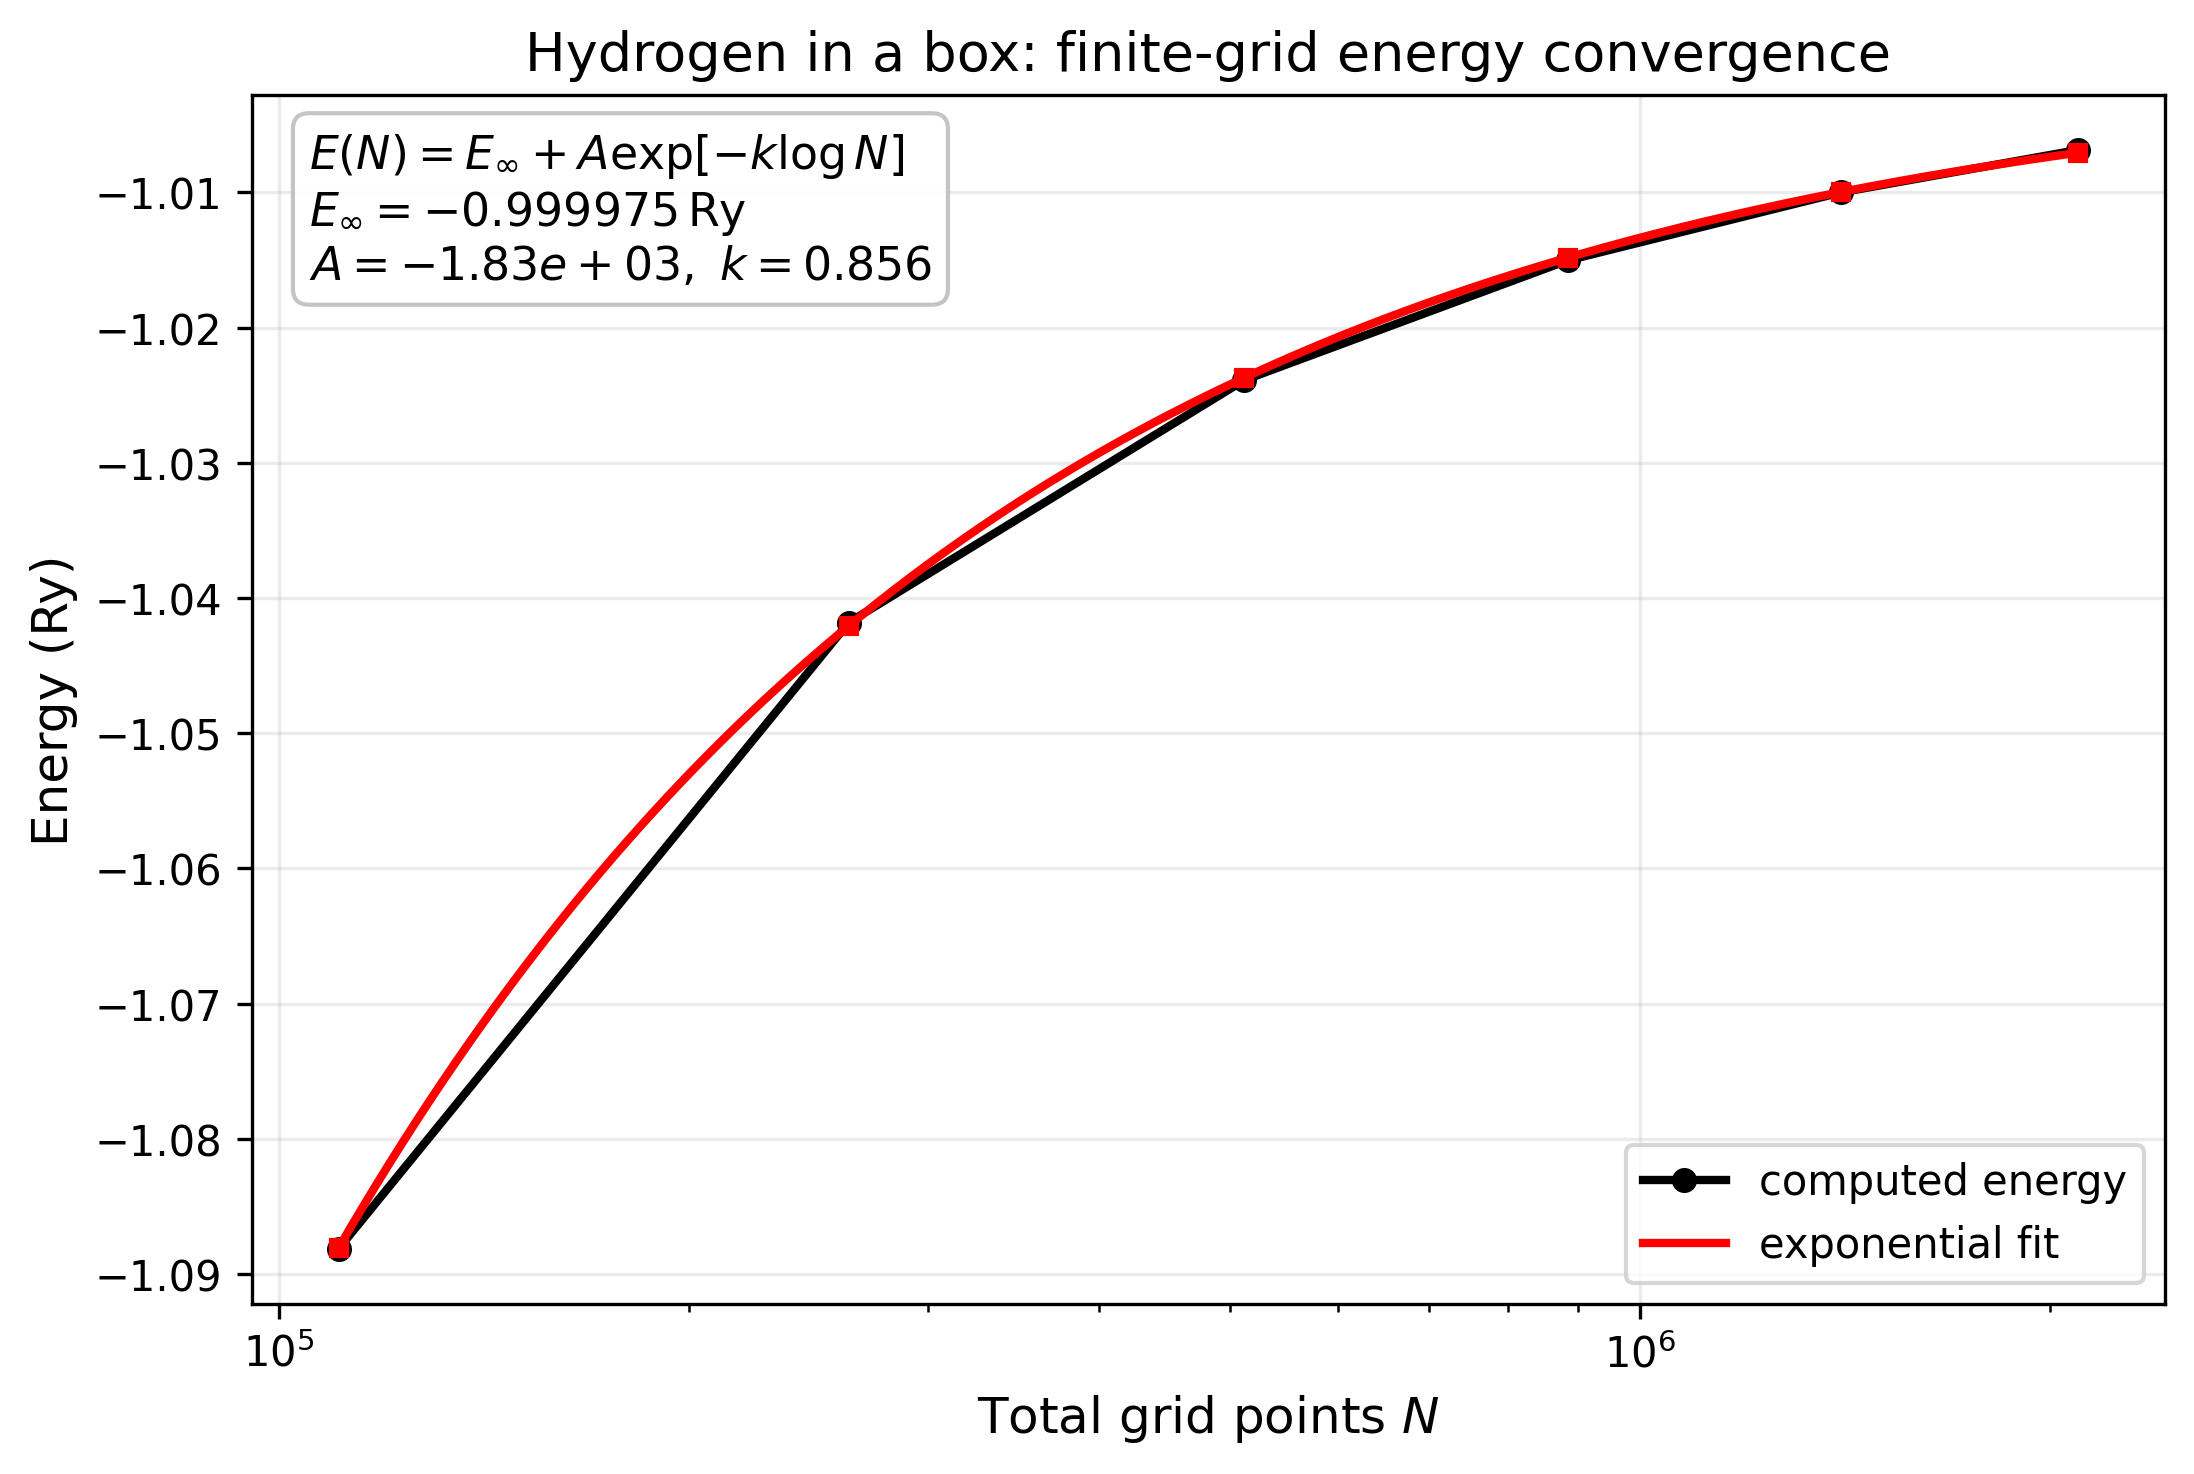

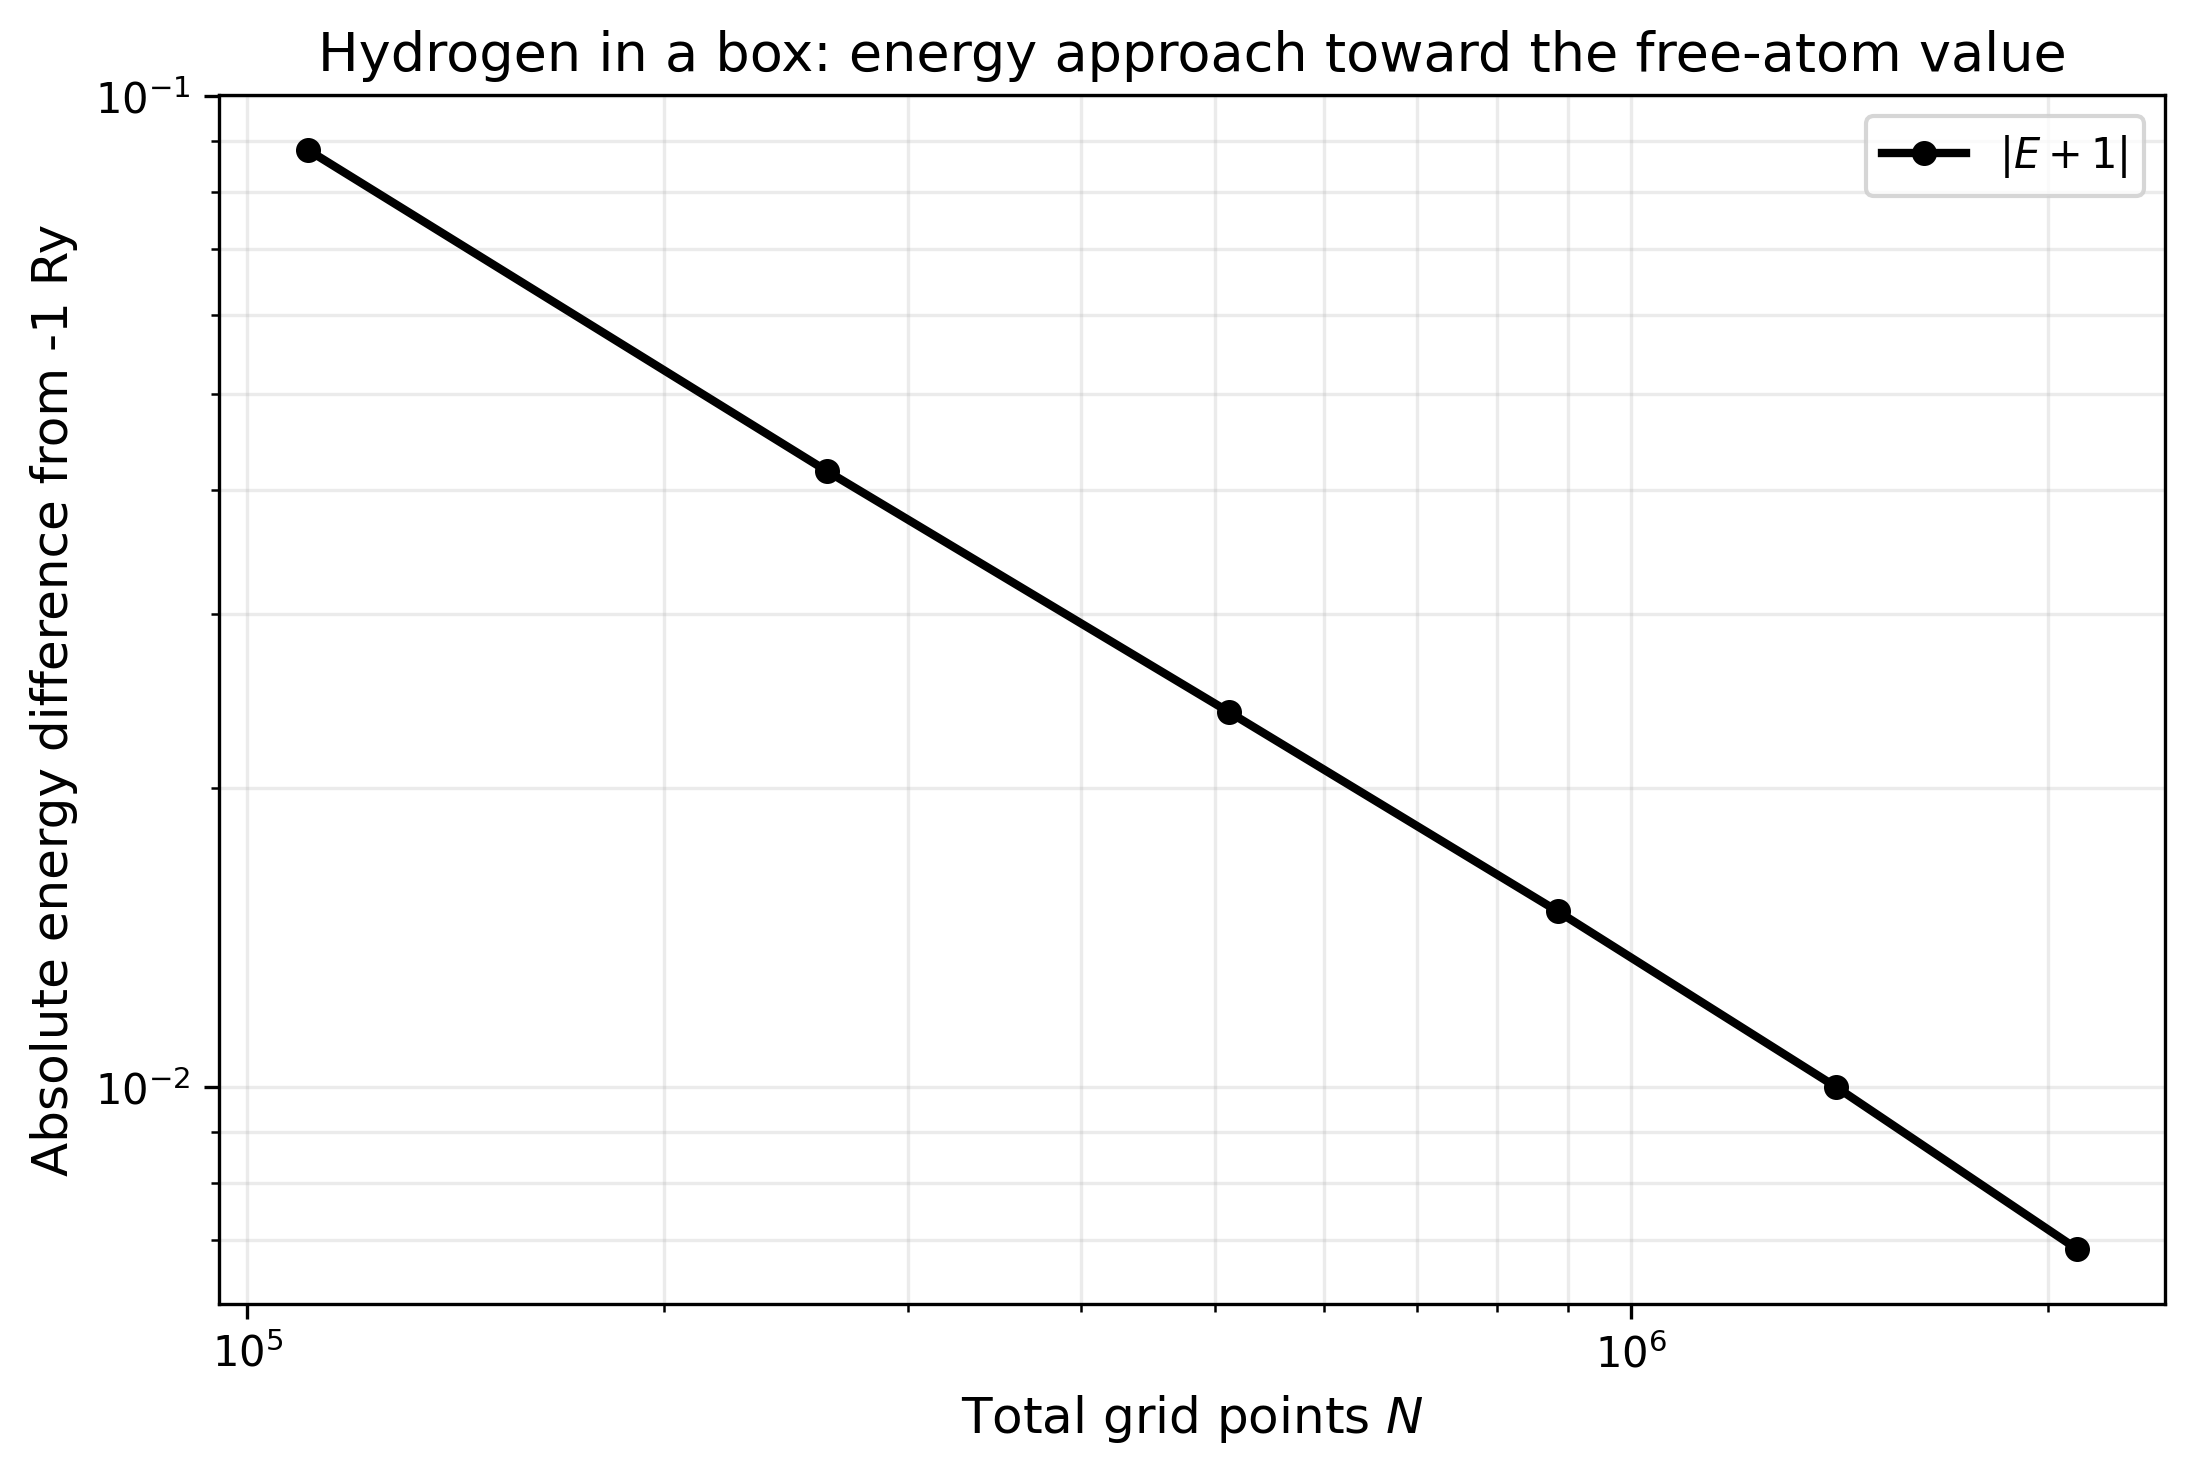

In [20]:
# Use the newest hydrogen sweep CSV, whether local or in Drive.
import subprocess

hyd_csv = latest_csv("hydrogen_scaling.csv")
HYD_OUT = hyd_csv.parent
print("Using hydrogen sweep folder:", HYD_OUT)
print("Using CSV:", hyd_csv)

subprocess.run([
    "python", "scripts/plot_hydrogen_sweep.py",
    str(hyd_csv),
    "--outdir", str(HYD_OUT),
    "--pdf",
], check=True)

display(Image(str(HYD_OUT / "hydrogen_energy_vs_gridpoints.png")))
display(Image(str(HYD_OUT / "hydrogen_energy_error_vs_gridpoints.png")))


## 13. Largest-\(N\) Hydrogen mid-slice heatmap

This automatically finds the largest \(N\) from the sweep and plots its saved mid-slice. This is the figure that should be used in the paper, not the small \(N=64\) diagnostic slice.


Largest N: 128
Looking for largest-N slice: results/hydrogen_n_sweep_quick/N_0128/psi_mid_z.csv
Saved: results/hydrogen_n_sweep_quick/N_0128/psi_mid_z_density_pretty.png
Saved: results/hydrogen_n_sweep_quick/N_0128/psi_mid_z_density_pretty.pdf


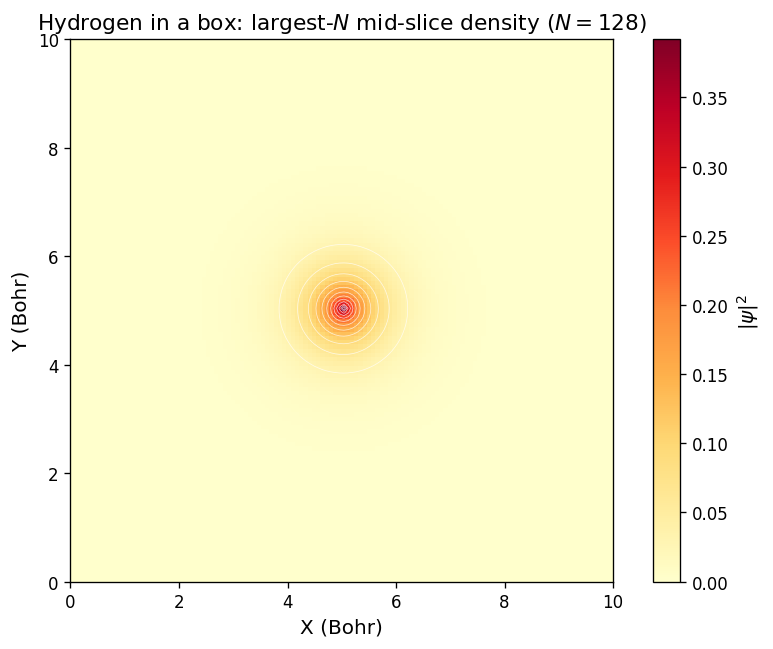

In [21]:
hyd = pd.read_csv(hyd_csv)
hyd = hyd.sort_values("n_per_dim")
largest = hyd.iloc[-1]
N_large = int(largest["n_per_dim"])
slice_dir = largest.get("slice_dir", "")

if not isinstance(slice_dir, str) or not slice_dir:
    # Fallback for older sweep outputs.
    slice_dir = str(HYD_OUT / f"N_{N_large:04d}")

slice_dir = Path(slice_dir)
slice_csv = slice_dir / "psi_mid_z.csv"
print("Largest N:", N_large)
print("Looking for largest-N slice:", slice_csv)

if not slice_csv.exists():
    print("Available hydrogen slices:")
    for p in sorted(HYD_OUT.glob("N_*/psi_mid_z.csv")):
        print(" ", p)
    raise FileNotFoundError(slice_csv)

box_large = infer_box_from_metadata(slice_dir, fallback=10.0)
pretty_hydrogen_slice(
    slice_csv,
    box=box_large,
    out_png=slice_dir / "psi_mid_z_density_pretty.png",
    title=fr"Hydrogen in a box: largest-$N$ mid-slice density ($N={N_large}$)",
)


# Part B — \( \mathrm{H}_2^+ \) molecular ion tests

These cells preserve the improved molecular workflow: energy curve, bond-plane heatmap, and transverse heatmap.


## 14. H\(_2^+\) quick curve run


In [15]:
!python examples/run_h2plus_curve.py \
    --n 128 \
    --box 16.0 \
    --r-values 0.8 1.0 1.2 1.4 1.6 1.8 2.0 2.2 2.5 3.0 3.5 4.0 \
    --sigma 0.5 \
    --tol 1e-7 \
    --max-iter 80000 \
    --check-every 20 \
    --out results/colab_h2plus_curve_48


Molecular midpoint = (0.0, 0.0, 0.0)
Grid spacing h = 1.259842519685e-01 Bohr
H2+ Coulomb centers are cell-centered in the two transverse directions; minimum possible transverse distance is 8.908432e-02 Bohr.
2026-07-05 13:52:21.108727: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1783259541.110220   16523 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5

=== H2+ separation R = 0.800000 Bohr ===
nucleus A = (0.0, 0.0, -0.4); nearest grid-node distance = 9.804335e-02 Bohr
nucleus B = (0.0, 0.0, 0.4); nearest grid-node distance = 9.804335e-02 Bohr
iter=      0  E=-1.238998115331e+00  residual=4.394e-01  norm=1.000000
iter=     20  E=-1.291176285183e+00  residual=3.216e-01  norm=1.000000
iter=     40  E=-

## 16. H\(_2^+\) energy curve plot


Using H2+ output folder: results/colab_h2plus_curve_48


,R_Bohr,electronic_energy_Ry,nuclear_repulsion_Ry,total_energy_Ry,iterations,converged,elapsed_seconds,tau,rmin_nucleus_A_Bohr,rmin_nucleus_B_Bohr
0,0.8,-3.097086,2.500000,-0.597086,5560,True,105.628580,0.001284,0.098043,0.098043
1,1.0,-2.893115,2.000000,-0.893115,4460,True,84.343484,0.001288,0.106881,0.106881
2,1.2,-2.718166,1.666667,-1.051499,4800,True,91.237767,0.001285,0.095025,0.095025
3,1.4,-2.564901,1.428571,-1.136330,5120,True,97.275478,0.001283,0.089366,0.089366
4,1.6,-2.427933,1.250000,-1.177933,5460,True,104.101567,0.001284,0.091067,0.091067
5,1.8,-2.306332,1.111111,-1.195221,5760,True,110.723431,0.001287,0.099752,0.099752
6,2.0,-2.200178,1.000000,-1.200178,6060,True,114.794741,0.001289,0.104757,0.104757
7,2.2,-2.107377,0.909091,-1.198287,6360,True,121.000773,0.001285,0.093727,0.093727
8,2.5,-1.983432,0.800000,-1.183432,7020,True,134.043739,0.001289,0.103735,0.103735
9,3.0,-1.818062,0.666667,-1.151395,8040,True,154.378055,0.001289,0.102740,0.102740


Saved: results/colab_h2plus_curve_48/h2plus_curve_pretty.png
Saved: results/colab_h2plus_curve_48/h2plus_curve_pretty.pdf


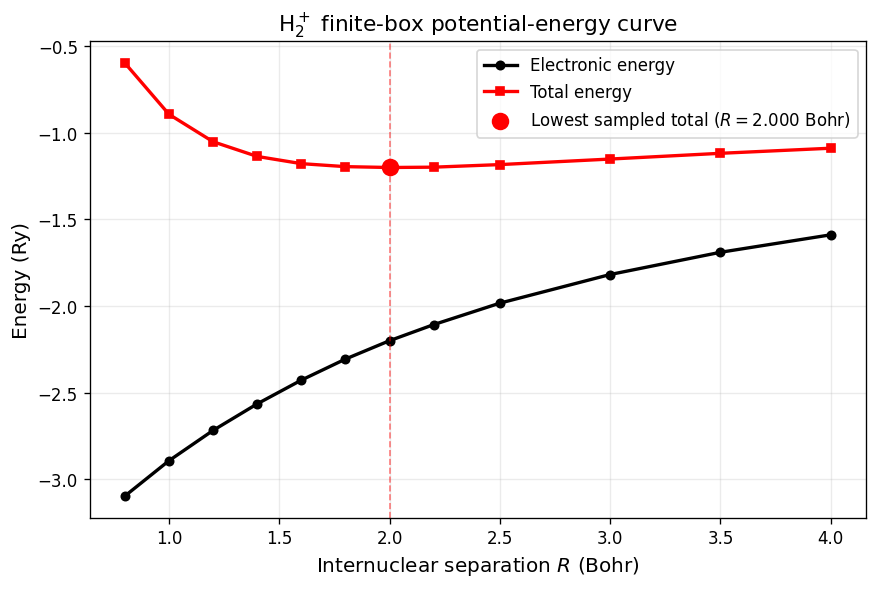

Lowest sampled total-energy point: R = 2.000000 Bohr, E_total = -1.200177809337 Ry


In [16]:
h2_csv = latest_csv("h2plus_curve.csv")
H2_OUT = h2_csv.parent
print("Using H2+ output folder:", H2_OUT)
h2 = pd.read_csv(h2_csv)
display(h2)

idx, R_best, E_best = nice_energy_plot(h2, H2_OUT / "h2plus_curve_pretty.png")
print(f"Lowest sampled total-energy point: R = {R_best:.6f} Bohr, E_total = {E_best:.12f} Ry")


## 17. H\(_2^+\) bond-plane heatmap

This is the main molecular wavefunction figure. It contains the bond axis and marks both protons.


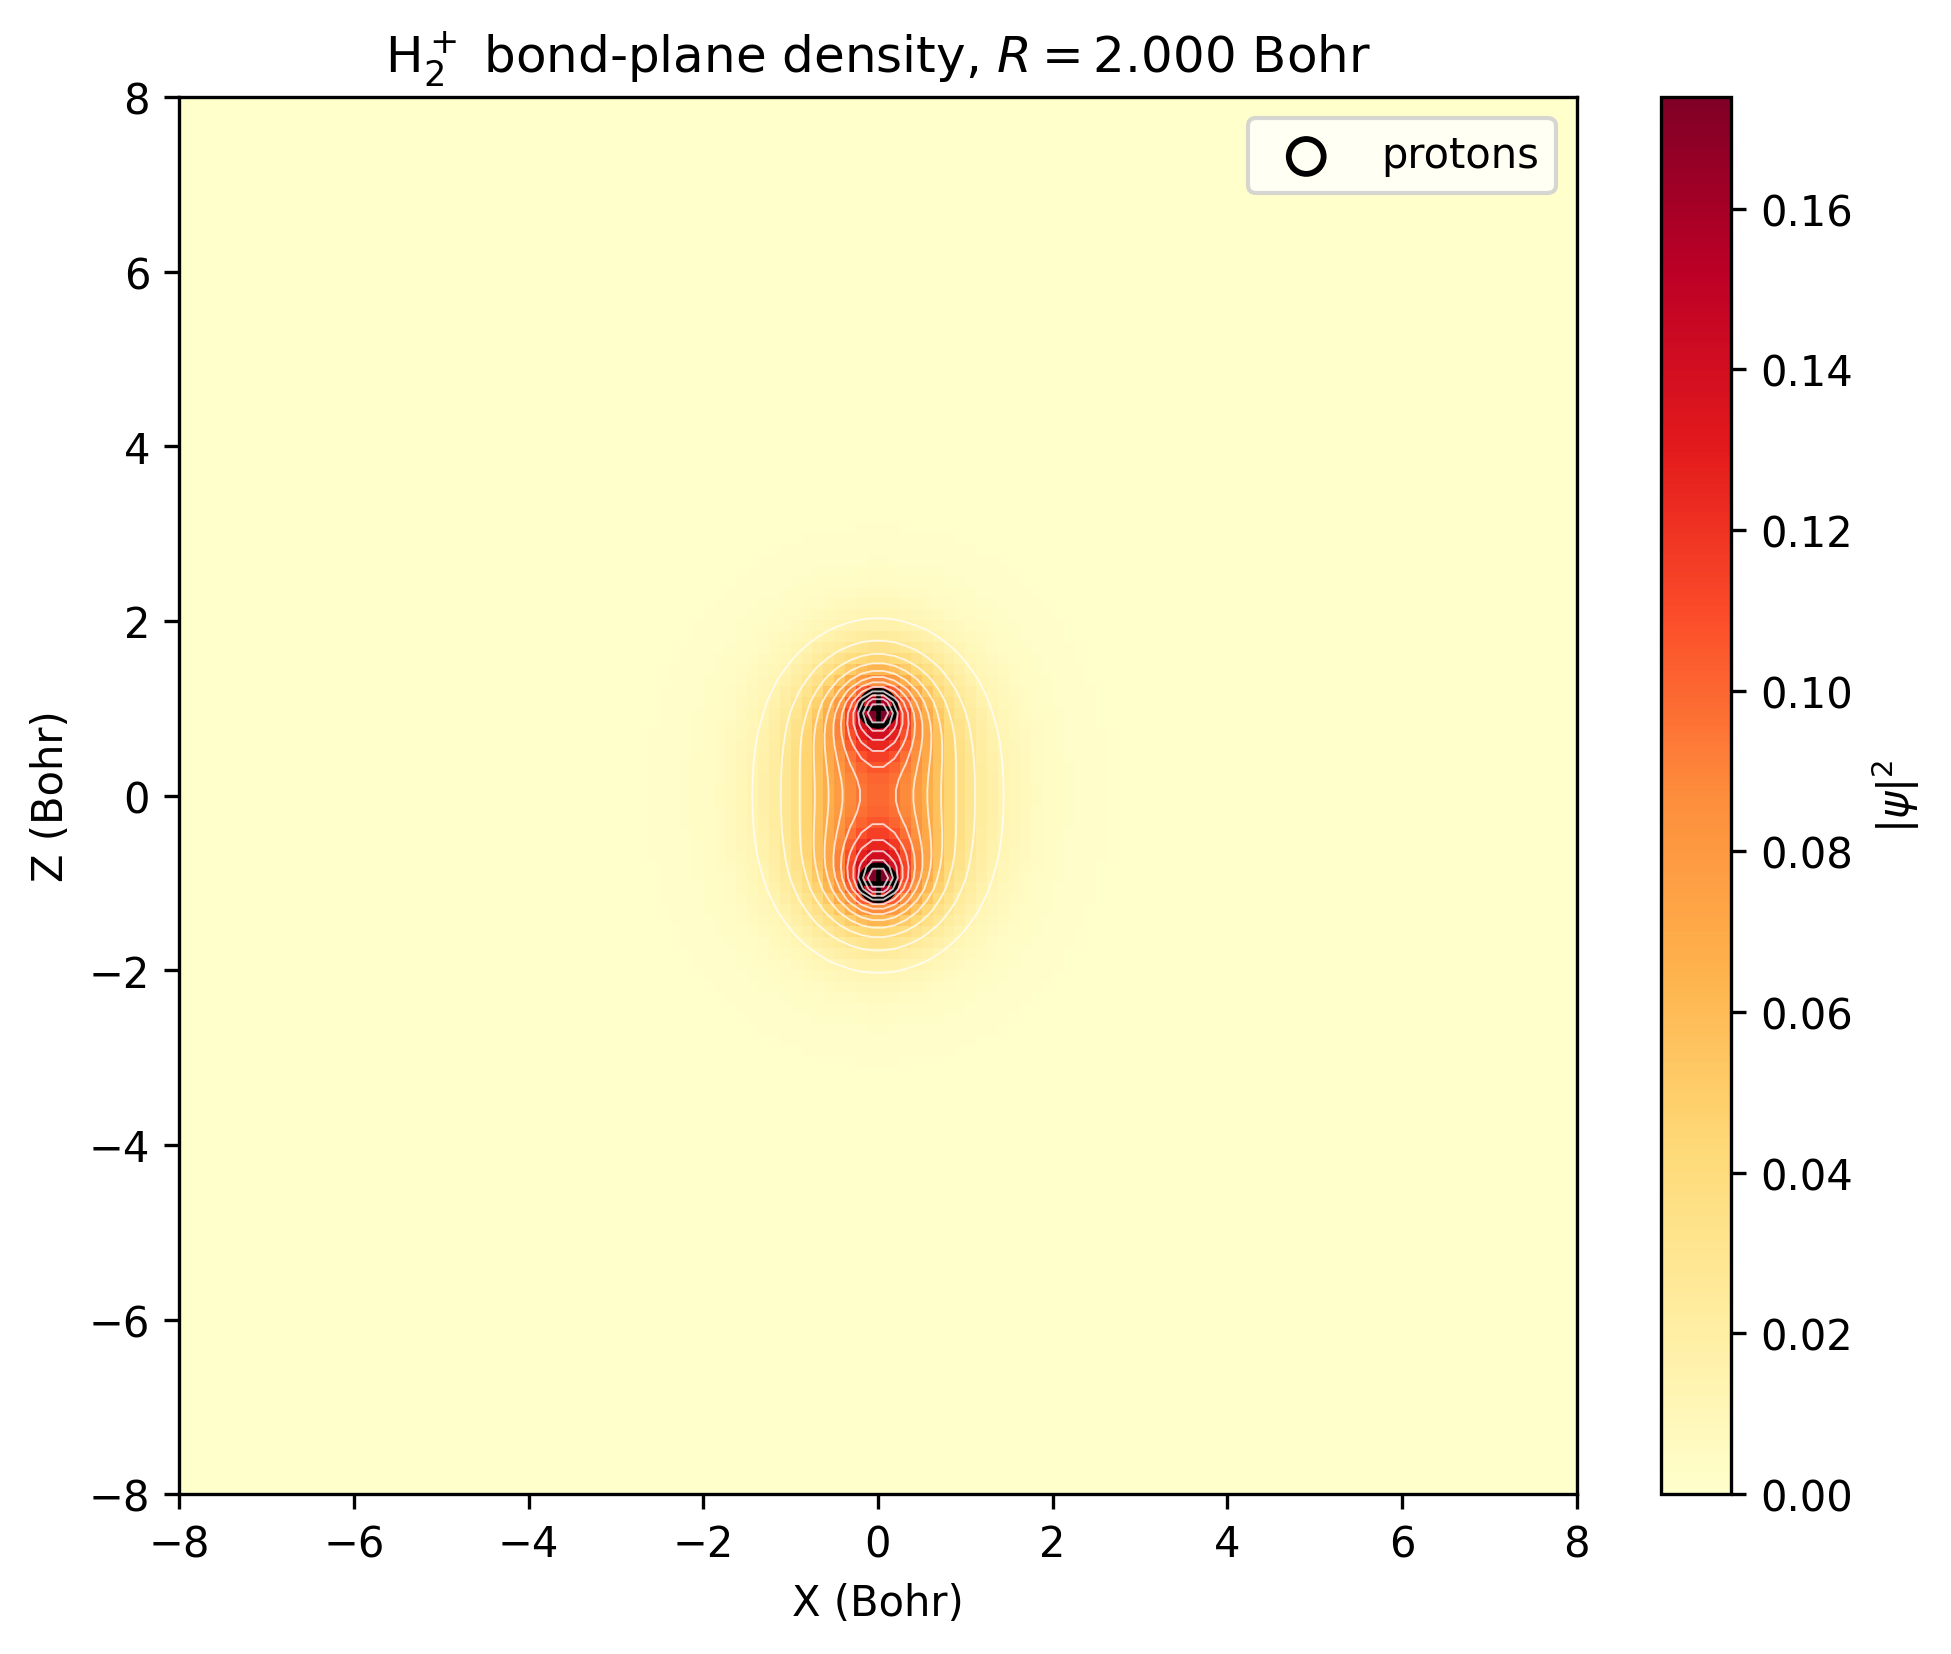

In [17]:
import subprocess

subprocess.run([
    "python", "scripts/plot_h2plus_slices.py",
    str(H2_OUT),
    "--R", "best",
    "--plane", "bond",
    "--pdf",
], check=True)

# Display the generated PNG.
bond_candidates = sorted(H2_OUT.glob("R_*/h2plus_bond_density_pretty.png"))
if not bond_candidates:
    raise FileNotFoundError("No H2+ bond-plane PNG was generated.")
display(Image(str(max(bond_candidates, key=lambda p: p.stat().st_mtime))))


## 18. H\(_2^+\) transverse mid-slice heatmap

This is a supplementary molecular figure showing the transverse density through the molecular midpoint.


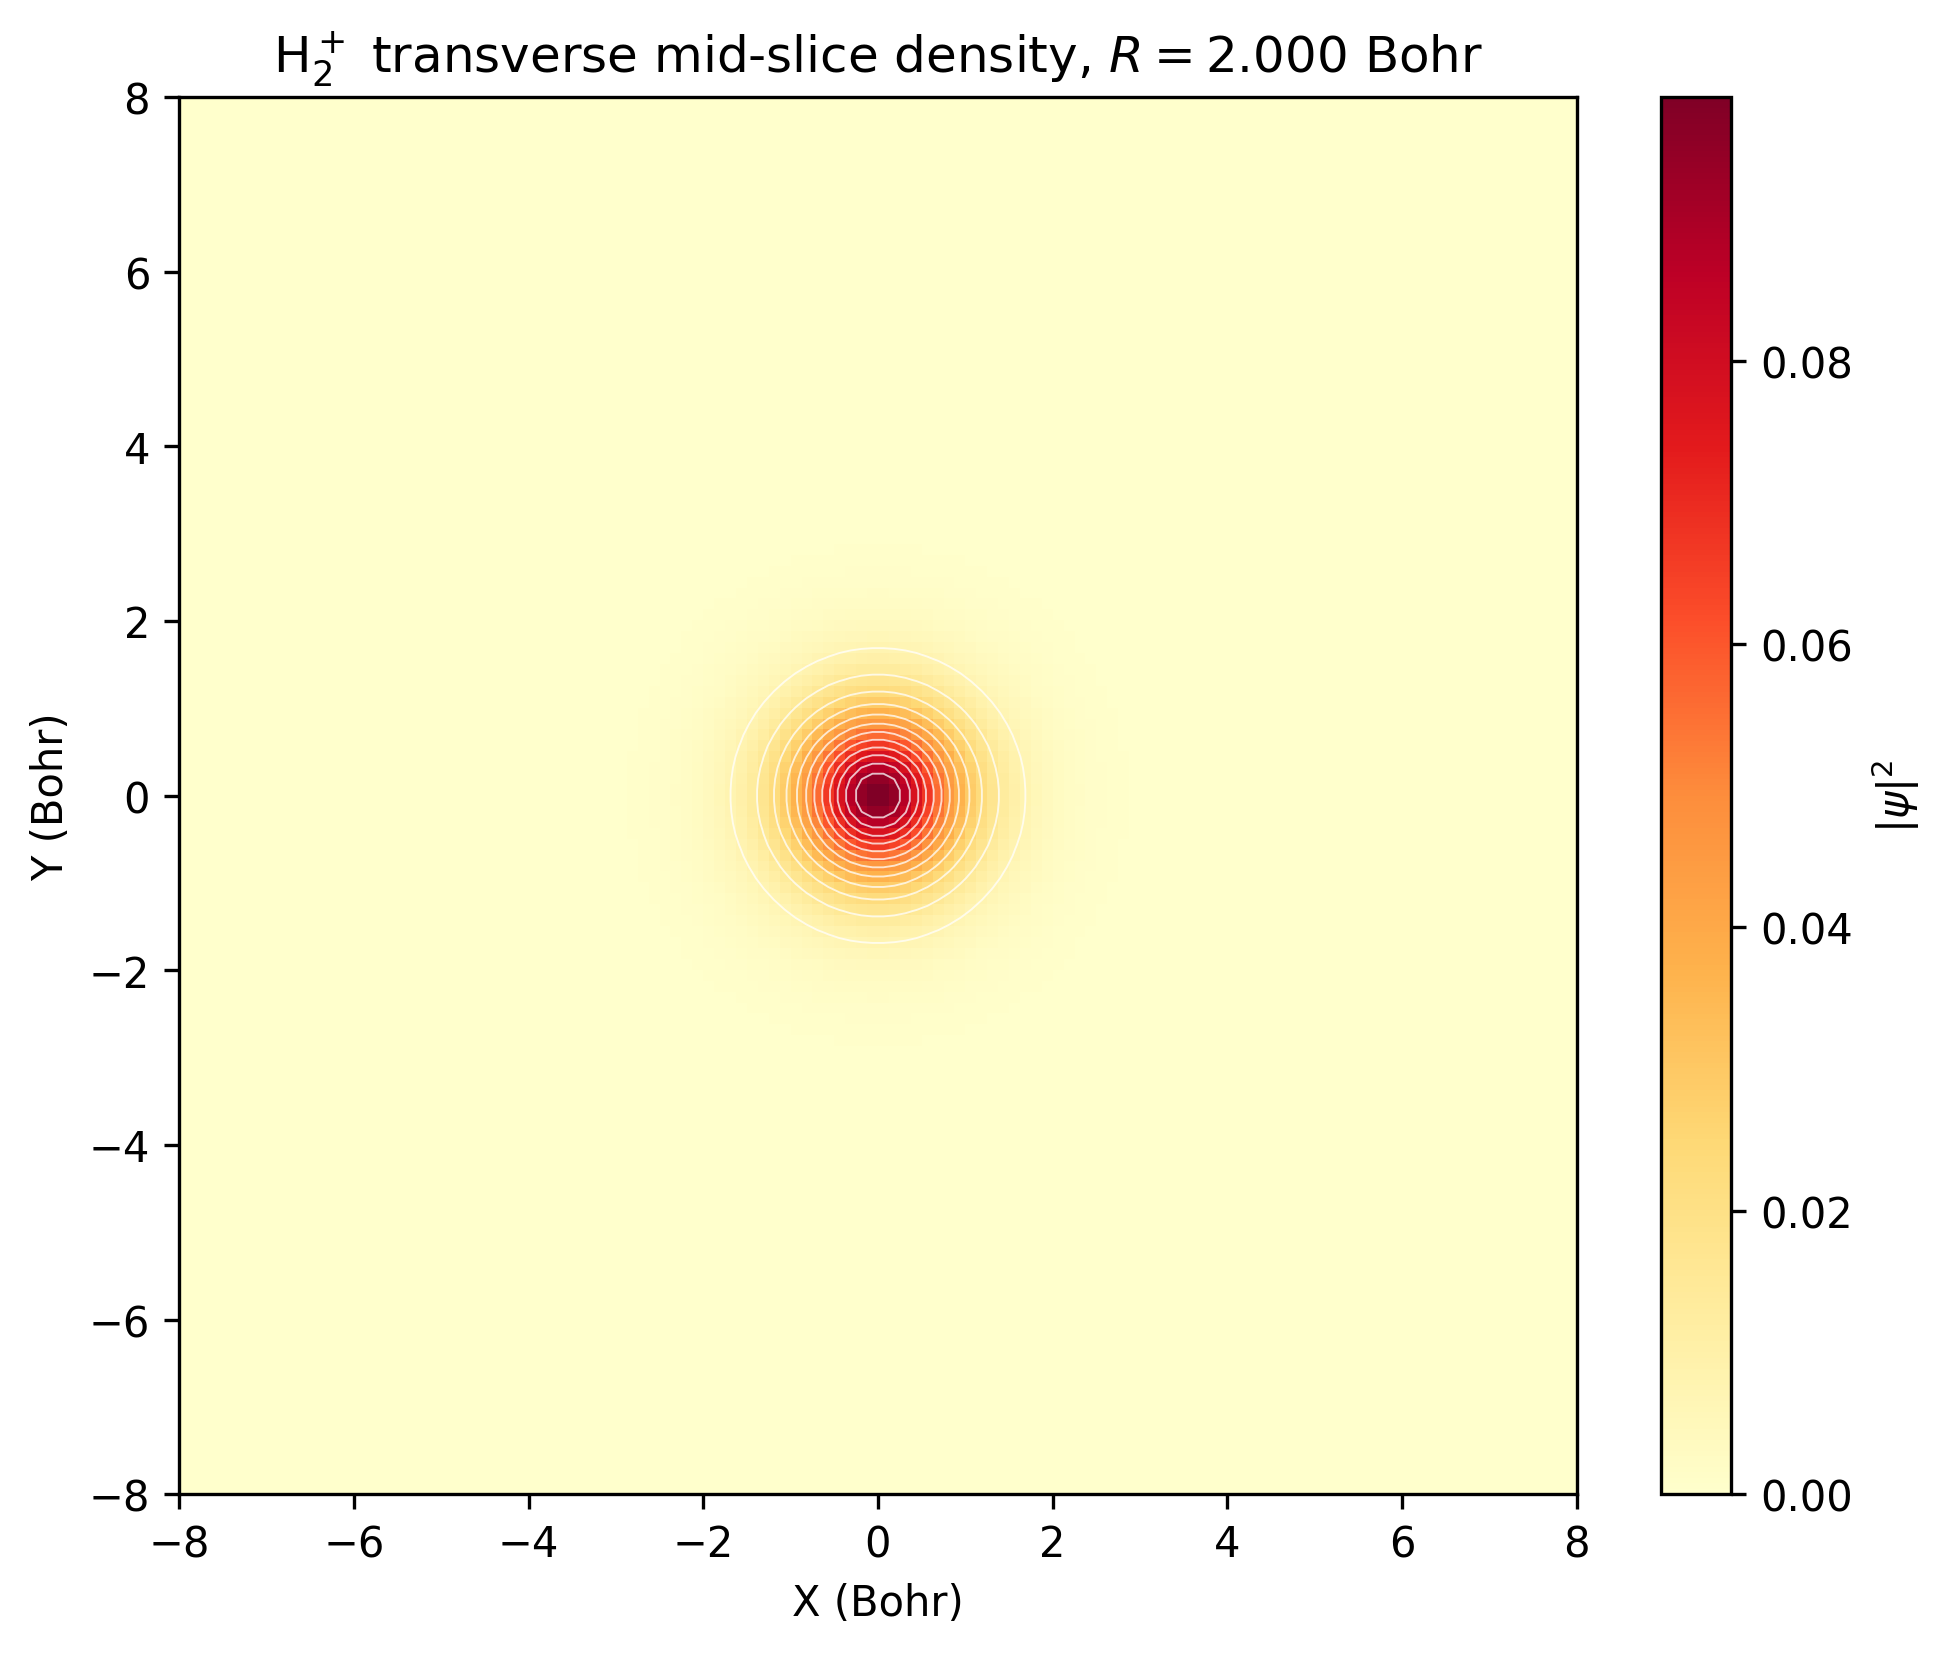

In [18]:
import subprocess

subprocess.run([
    "python", "scripts/plot_h2plus_slices.py",
    str(H2_OUT),
    "--R", "best",
    "--plane", "transverse",
    "--pdf",
], check=True)

trans_candidates = sorted(H2_OUT.glob("R_*/h2plus_transverse_density_pretty.png"))
if not trans_candidates:
    raise FileNotFoundError("No H2+ transverse PNG was generated.")
display(Image(str(max(trans_candidates, key=lambda p: p.stat().st_mtime))))


## 19. Copy local results to Google Drive

Use this after local quick runs if Drive is mounted.


In [ ]:
# !mkdir -p /content/drive/MyDrive/mrsr_results
# !cp -r results/* /content/drive/MyDrive/mrsr_results/
